# Standard Cost Comparison For All Materials
Plan is to update current standard costs to have a standardized formula below.<br>
$$\text{new\_std\_cost} = \text{avg\_cost} × (1 + markup)$$
Based from the smaller pvc material sample run. 25%, 30%, and 35% all seem fair new average costs. We could possibly even go higher.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_excel('Materials Master.xlsx')
df.head()

,item_no,item_desc_1,item_desc_2,prod_cat,uom,qty_on_hand,qty_allocated,qty_on_ord,reorder_lvl,ord_up_to_lvl,...,std_cost,usage_ptd,usage_ytd,prior_year_usage,bin_no,activity_cd,ytd cost,prior yr $,on hand $,inv level #$
0,010050060096020,BLACK TRESPA,1/2 X 60 X 96,NaN,EA,1,0,0,0,0,...,367.29000,0,0,0,5612,A,0.0,0.0,232.0,0.0
1,010062572096034,TRESPA TOPLAB T.03.40 SILVER,GRAY 5/8X72X96,NaN,SH,3,0,0,0,0,...,724.00207,0,0,3,CUTTING,A,0.0,1478.4,1478.4,0.0
2,010075072096034,TRESPA TOPLAB PLUS SILVERGRAY,3/4X72X96 COLOR 0340,NaN,SH,0,0,0,0,0,...,1075.26595,0,0,0,4706,A,0.0,0.0,0.0,0.0
3,011006024048010,ABS SHEET NATURAL,.060 X 24 X 48 VACUUM FORMING,011,SH,0,0,0,0,0,...,15.52320,0,0,0,NOBIN,O,0.0,0.0,0.0,0.0
4,011006024048110,ABS SHEET BLACK,.060 X 24 X 48 VACUUM FORMING,011,SH,0,0,0,0,0,...,15.52320,0,0,0,NOBIN,O,0.0,0.0,0.0,0.0


## Cleaning

Full materials list contains "catch all" part #s such as: A, B, MFG, MFL, OFFICE, etc. <br>
These all need to be filtered out along with any row that will interfere with the formulas (average or standard costs = 0). These will be flagged for review.

In [2]:
item = df['item_no'].astype(str)
is_material = item.str[0].str.isdigit()
excluded = df[~is_material]
df = df[is_material].copy()
df['avg_cost'] = pd.to_numeric(df['avg_cost'], errors='coerce')
df['std_cost'] = pd.to_numeric(df['std_cost'], errors='coerce')
df['avg_cost_missing'] = (df['avg_cost'] == 0) | df['avg_cost'].isna()
df['std_cost_missing'] = (df['std_cost'] == 0) | df['std_cost'].isna()

print(f'Number of Rows With Bad Part #s = {len(excluded)}')
print(f'Number of Rows With Good Part #s = {len(df)}')
print(f'Number of Rows Where Average is 0 = {df["avg_cost_missing"].sum()}')
print(f'Number of Rows Where Standard is 0 = {df["std_cost_missing"].sum()}')
print(f'Number of Rows Good = {(~df["avg_cost_missing"] & ~df["std_cost_missing"]).sum()}')

Number of Rows With Bad Part #s = 67
Number of Rows With Good Part #s = 5706
Number of Rows Where Average is 0 = 1218
Number of Rows Where Standard is 0 = 495
Number of Rows Good = 4276


## Apply Formulas

In [3]:
valid = df[(~df['avg_cost_missing']) & (~df['std_cost_missing'])].copy()
x = np.log(valid['avg_cost'])
y = np.log(valid['std_cost'])
ratio = valid['std_cost'] / valid['avg_cost']
lo, hi = ratio.quantile(0.01), ratio.quantile(0.99)
keep = (ratio >= lo) & (ratio <= hi)
b, a = np.polyfit(x[keep], y[keep], 1)
yhat = a + b * x[keep]
r2 = 1 - ((y[keep] - yhat) ** 2).sum() / ((y[keep] - y[keep].mean()) ** 2).sum()
implied_markup = np.exp(a) - 1
median_markup  = ratio.median() - 1
print(f'log(std_cost)-log(avg_cost), trimmed n={int(keep.sum())}(# of rows)')
print(f'slope b = {b}(basically 1)')
print(f'intercept a = {a}(exp(a) = {np.exp(a)})')
print(f'R^2 = {r2}')
print(f'Markup From Intercept = {implied_markup*100}%')
print(f'Markup From Median = {median_markup*100}%({median_markup} basically 0.47)')

log(std_cost)-log(avg_cost), trimmed n=4190(# of rows)
slope b = 0.9978745631758831(basically 1)
intercept a = 0.4008130677667508(exp(a) = 1.4930381454573693)
R^2 = 0.9816937842523553
Markup From Intercept = 49.303814545736934%
Markup From Median = 46.916000000000004%(0.46916 basically 0.47)


In [4]:
markups = [0.25, 0.30, 0.35, 0.47]
for m in markups:
    pct = int(m * 100)
    df[f'new_std_{pct}'] = df['avg_cost'] * (1 + m)
    df[f'diff_{pct}']    = df[f'new_std_{pct}'] - df['std_cost']
    df[f'pct_change_{pct}'] = np.where(df['std_cost'] == 0, np.nan, (df[f'new_std_{pct}'] - df['std_cost']) / df['std_cost'])
df.head()

,item_no,item_desc_1,item_desc_2,prod_cat,uom,qty_on_hand,qty_allocated,qty_on_ord,reorder_lvl,ord_up_to_lvl,...,pct_change_25,new_std_30,diff_30,pct_change_30,new_std_35,diff_35,pct_change_35,new_std_47,diff_47,pct_change_47
0,010050060096020,BLACK TRESPA,1/2 X 60 X 96,NaN,EA,1,0,0,0,0,...,-0.210433,301.600,-65.69000,-0.178850,313.2000,-54.09000,-0.147268,341.0400,-26.25000,-0.071469
1,010062572096034,TRESPA TOPLAB T.03.40 SILVER,GRAY 5/8X72X96,NaN,SH,3,0,0,0,0,...,-0.149174,640.640,-83.36207,-0.115141,665.2800,-58.72207,-0.081108,724.4160,0.41393,0.000572
2,010075072096034,TRESPA TOPLAB PLUS SILVERGRAY,3/4X72X96 COLOR 0340,NaN,SH,0,0,0,0,0,...,-0.071823,1037.959,-37.30695,-0.034696,1077.8805,2.61455,0.002432,1173.6921,98.42615,0.091537
3,011006024048010,ABS SHEET NATURAL,.060 X 24 X 48 VACUUM FORMING,011,SH,0,0,0,0,0,...,-0.029678,15.665,0.14180,0.009135,16.2675,0.74430,0.047948,17.7135,2.19030,0.141098
4,011006024048110,ABS SHEET BLACK,.060 X 24 X 48 VACUUM FORMING,011,SH,0,0,0,0,0,...,0.256184,20.280,4.75680,0.306432,21.0600,5.53680,0.356679,22.9320,7.40880,0.477273


## Output Table

In [5]:
cols = ['item_no', 'item_desc_1', 'item_desc_2', 'avg_cost', 'std_cost', 'new_std_25', 'diff_25', 'pct_change_25', 'new_std_30', 'diff_30', 'pct_change_30', 'new_std_35', 'diff_35', 'pct_change_35', 'new_std_47', 'diff_47', 'pct_change_47', 'avg_cost_missing', 'std_cost_missing']
comparison = df[cols].copy()
comparison.sample(10).style.format({'avg_cost': '${:,.2f}', 'std_cost': '${:,.2f}', 'new_std_25': '${:,.2f}', 'new_std_30': '${:,.2f}', 'new_std_35': '${:,.2f}', 'new_std_47': '${:,.2f}', 'diff_25': '${:,.2f}', 'diff_30': '${:,.2f}', 'diff_35': '${:,.2f}', 'diff_47': '${:,.2f}', 'pct_change_25': '{:.1%}', 'pct_change_30': '{:.1%}', 'pct_change_35': '{:.1%}', 'pct_change_47': '{:.1%}',})

,item_no,item_desc_1,item_desc_2,avg_cost,std_cost,new_std_25,diff_25,pct_change_25,new_std_30,diff_30,pct_change_30,new_std_35,diff_35,pct_change_35,new_std_47,diff_47,pct_change_47,avg_cost_missing,std_cost_missing
2931,2420312000,POLY CARBONATE ROD,5/16 DIA CLEAR,$0.00,$1.03,$0.00,$-1.03,-100.0%,$0.00,$-1.03,-100.0%,$0.00,$-1.03,-100.0%,$0.00,$-1.03,-100.0%,True,False
4770,421100048096220,PP SHT BLK SR 1X48X96,FILM MASKED,$279.41,$480.60,$349.26,$-131.34,-27.3%,$363.23,$-117.37,-24.4%,$377.20,$-103.40,-21.5%,$410.73,$-69.87,-14.5%,False,False
3809,313S42A,FLEXIBLE VINYL TUBING,2 X 2 3/4 CLEAR,$0.00,$13.75,$0.00,$-13.75,-100.0%,$0.00,$-13.75,-100.0%,$0.00,$-13.75,-100.0%,$0.00,$-13.75,-100.0%,True,False
1645,151025048120020,1/4 X 48 X 120 NAT CANVAS,PHENOLIC,$331.99,$421.79,$414.99,$-6.81,-1.6%,$431.59,$9.79,2.3%,$448.19,$26.39,6.3%,$488.02,$66.23,15.7%,False,False
2984,243175016250000,POLY CARBONATE TUBE,1 3/4' OD X 1 5/8' ID CLEAR,$1.75,$2.15,$2.19,$0.04,1.8%,$2.27,$0.13,5.9%,$2.36,$0.21,10.0%,$2.57,$0.42,19.8%,False,False
751,0440100017,"1"" Black Acylic Ext Rod",nan,$0.94,$2.15,$1.17,$-0.97,-45.3%,$1.22,$-0.93,-43.1%,$1.27,$-0.88,-40.9%,$1.38,$-0.77,-35.7%,False,False
4282,3830150001580SV,TEFLON TUBING,1.500 ID X 1.580 OD,$0.00,$8.95,$0.00,$-8.95,-100.0%,$0.00,$-8.95,-100.0%,$0.00,$-8.95,-100.0%,$0.00,$-8.95,-100.0%,True,False
438,041012548096110,".125"" x 48"" x 96"" Clear Ext.",Acrylic Paper Mask,$48.00,$80.50,$60.00,$-20.50,-25.5%,$62.40,$-18.10,-22.5%,$64.80,$-15.70,-19.5%,$70.56,$-9.94,-12.3%,False,False
2590,2270012524048,NYLATRON GSM SHEET,1/8 X 24 X 48,$0.00,$0.00,$0.00,$0.00,nan%,$0.00,$0.00,nan%,$0.00,$0.00,nan%,$0.00,$0.00,nan%,True,True
629,04305250001870,CAST ACRYLIC TUBING,5 1/4 OD X 3/16 WALL,$0.00,$11.73,$0.00,$-11.73,-100.0%,$0.00,$-11.73,-100.0%,$0.00,$-11.73,-100.0%,$0.00,$-11.73,-100.0%,True,False


## Clean Output
Filter out rows where average and standard cost = 0.

In [6]:
print(f'{len(valid)} Good Rows Out of {len(df)}')
rows = []
valid = df[(~df['avg_cost_missing']) & (~df['std_cost_missing'])].copy()
for m in markups:
    pct = int(m * 100)
    diff = valid[f'diff_{pct}']
    pct_change = valid[f'pct_change_{pct}']
    rows.append({'scenario': f'{pct}% Above Average Cost', 'items_higher': int((diff > 0).sum()), 'items_lower': int((diff < 0).sum()), 'items_unchanged': int((diff == 0).sum()), 'mean_diff': diff.mean(), 'median_diff': diff.median(), 'total_diff': diff.sum(), 'mean_pct_change': pct_change.mean(),})

summary = pd.DataFrame(rows)
summary.style.format({'mean_diff': '${:,.2f}', 'median_diff': '${:,.2f}', 'total_diff': '${:,.2f}', 'mean_pct_change': '{:.1%}',})

4276 Good Rows Out of 5706


,scenario,items_higher,items_lower,items_unchanged,mean_diff,median_diff,total_diff,mean_pct_change
0,25% Above Average Cost,1167,3057,52,$-30.93,$-1.22,"$-132,277.30",5.9%
1,30% Above Average Cost,1393,2883,0,$-24.65,$-0.84,"$-105,392.24",10.1%
2,35% Above Average Cost,1522,2754,0,$-18.36,$-0.54,"$-78,507.18",14.3%
3,47% Above Average Cost,2439,1837,0,$-3.27,$0.01,"$-13,983.04",24.5%


## Linear Regression

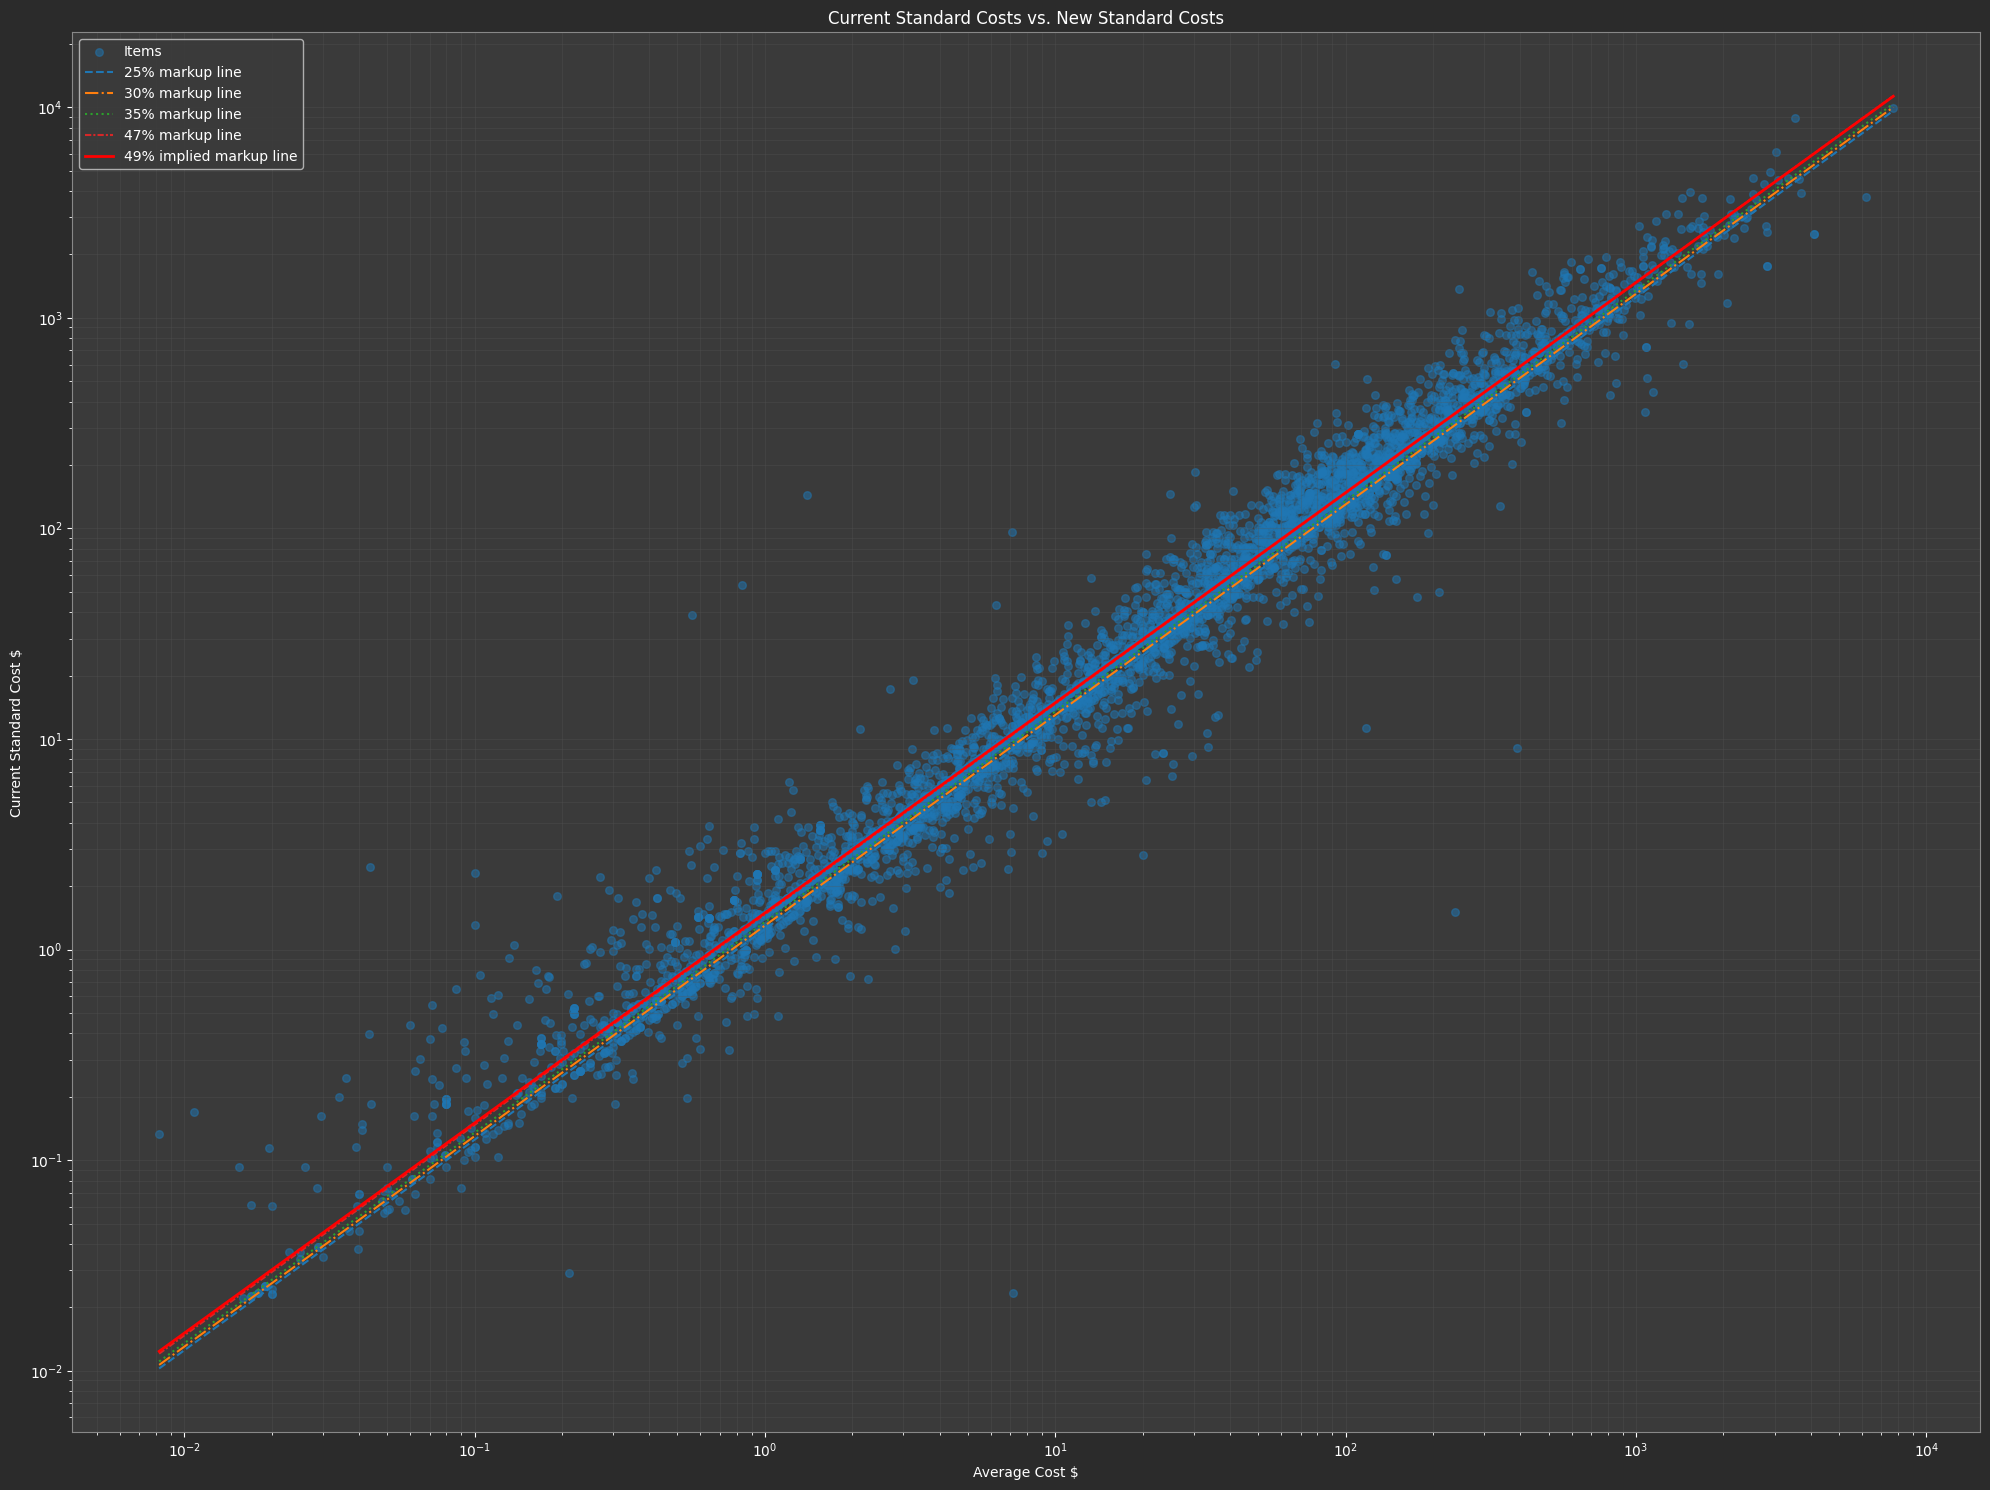

In [7]:
plt.rcParams['figure.facecolor'] = '#2b2b2b'
plt.rcParams['axes.facecolor'] = '#3a3a3a'
plt.rcParams['axes.edgecolor'] = '#888'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['grid.color'] = '#555'
plt.rcParams['axes.titlecolor'] = 'white'

fig, ax = plt.subplots(figsize=(20, 15))
ax.scatter(valid['avg_cost'], valid['std_cost'], alpha=0.5, s=30, label='Items')
x = np.linspace(valid['avg_cost'].min(), valid['avg_cost'].max(), 100)
for m, style in zip(markups, ['--', '-.', ':', (0, (3, 1, 1, 1))]):
    ax.plot(x, x * (1 + m), linestyle=style, label=f'{int(m*100)}% markup line')

ax.plot(x, np.exp(a) * x ** b, color='red', linewidth=2, label=f'{implied_markup*100:.0f}% implied markup line')
ax.set_xlabel('Average Cost $')
ax.set_ylabel('Current Standard Cost $')
ax.set_title('Current Standard Costs vs. New Standard Costs')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

Materials above the markup lines have current standard costs higher (unrealistic for pricing)<br>
Materials under the markup lines have lower current standard costs (possibly underpricing final sales).

## Materials w/ Current Standard Costs Under Lowest Markup (25%)
Return materials that have standard costs that are currently lower than the lowest planned markup.

In [8]:
above = valid[valid['diff_25'] > 0].sort_values('diff_25', ascending=False)
print(f'Rows Where 25% Markup > Current Standard = {len(above)}')
above[['item_no', 'item_desc_1', 'avg_cost', 'std_cost', 'new_std_25', 'diff_25']].head(20)

Rows Where 25% Markup > Current Standard = 1167


,item_no,item_desc_1,avg_cost,std_cost,new_std_25,diff_25
2084,181075048096,KYNAR SHEET,6179.09,3738.65415,7723.8625,3985.20835
2078,181050048096,KYNAR SHEET,4119.40,2487.08460,5149.2500,2662.16540
2077,181050048096,KYNAR SHEET,4119.40,2487.08460,5149.2500,2662.16540
2069,181037548096,KYNAR SHEET,2823.53,1756.28145,3529.4125,1773.13105
2070,181037548096,KYNAR SHEET,2823.53,1756.28145,3529.4125,1773.13105
2064,181025048096,KYNAR SHEET,2059.70,1170.85815,2574.6250,1403.76685
2659,2310125024048,NYLATRON NSM SHEET,1447.28,602.20864,1809.1000,1206.89136
1936,1610025012012,KEL-F SHEET,1072.30,356.36370,1340.3750,984.01130
2606,2270150024048,NYLATRON GSM SHEET,1141.60,444.98685,1427.0000,982.01315
1247,081025002404800,ERTALYTE SHEET,2830.16,2561.22339,3537.7000,976.47661


## Find Outliers/Anomalies

As shown on the visualization above, there are many scattered outliers/anomalies. <br>
We will use an isolation forest to flag these.

In [9]:
from sklearn.ensemble import IsolationForest
anom = valid.copy()
anom['ratio'] = anom['std_cost'] / anom['avg_cost']
anom['log_ratio'] = np.log(anom['ratio'])

CONTAMINATION = 0.03
features = pd.DataFrame({'log_avg': np.log(anom['avg_cost']), 'log_std': np.log(anom['std_cost']), 'log_ratio': anom['log_ratio']})
iso = IsolationForest(n_estimators=300, contamination=CONTAMINATION, random_state=42)
anom['flag']  = iso.fit_predict(features) == -1
anom['score'] = -iso.score_samples(features)

print(f'Total Rows = {len(anom)}')
print(f'Median std/avg = {anom["ratio"].median():.3f}')
print(f'Rows Flagged = {anom["flag"].sum()}')

Total Rows = 4276
Median std/avg = 1.469
Rows Flagged = 129


## Isolation Forest

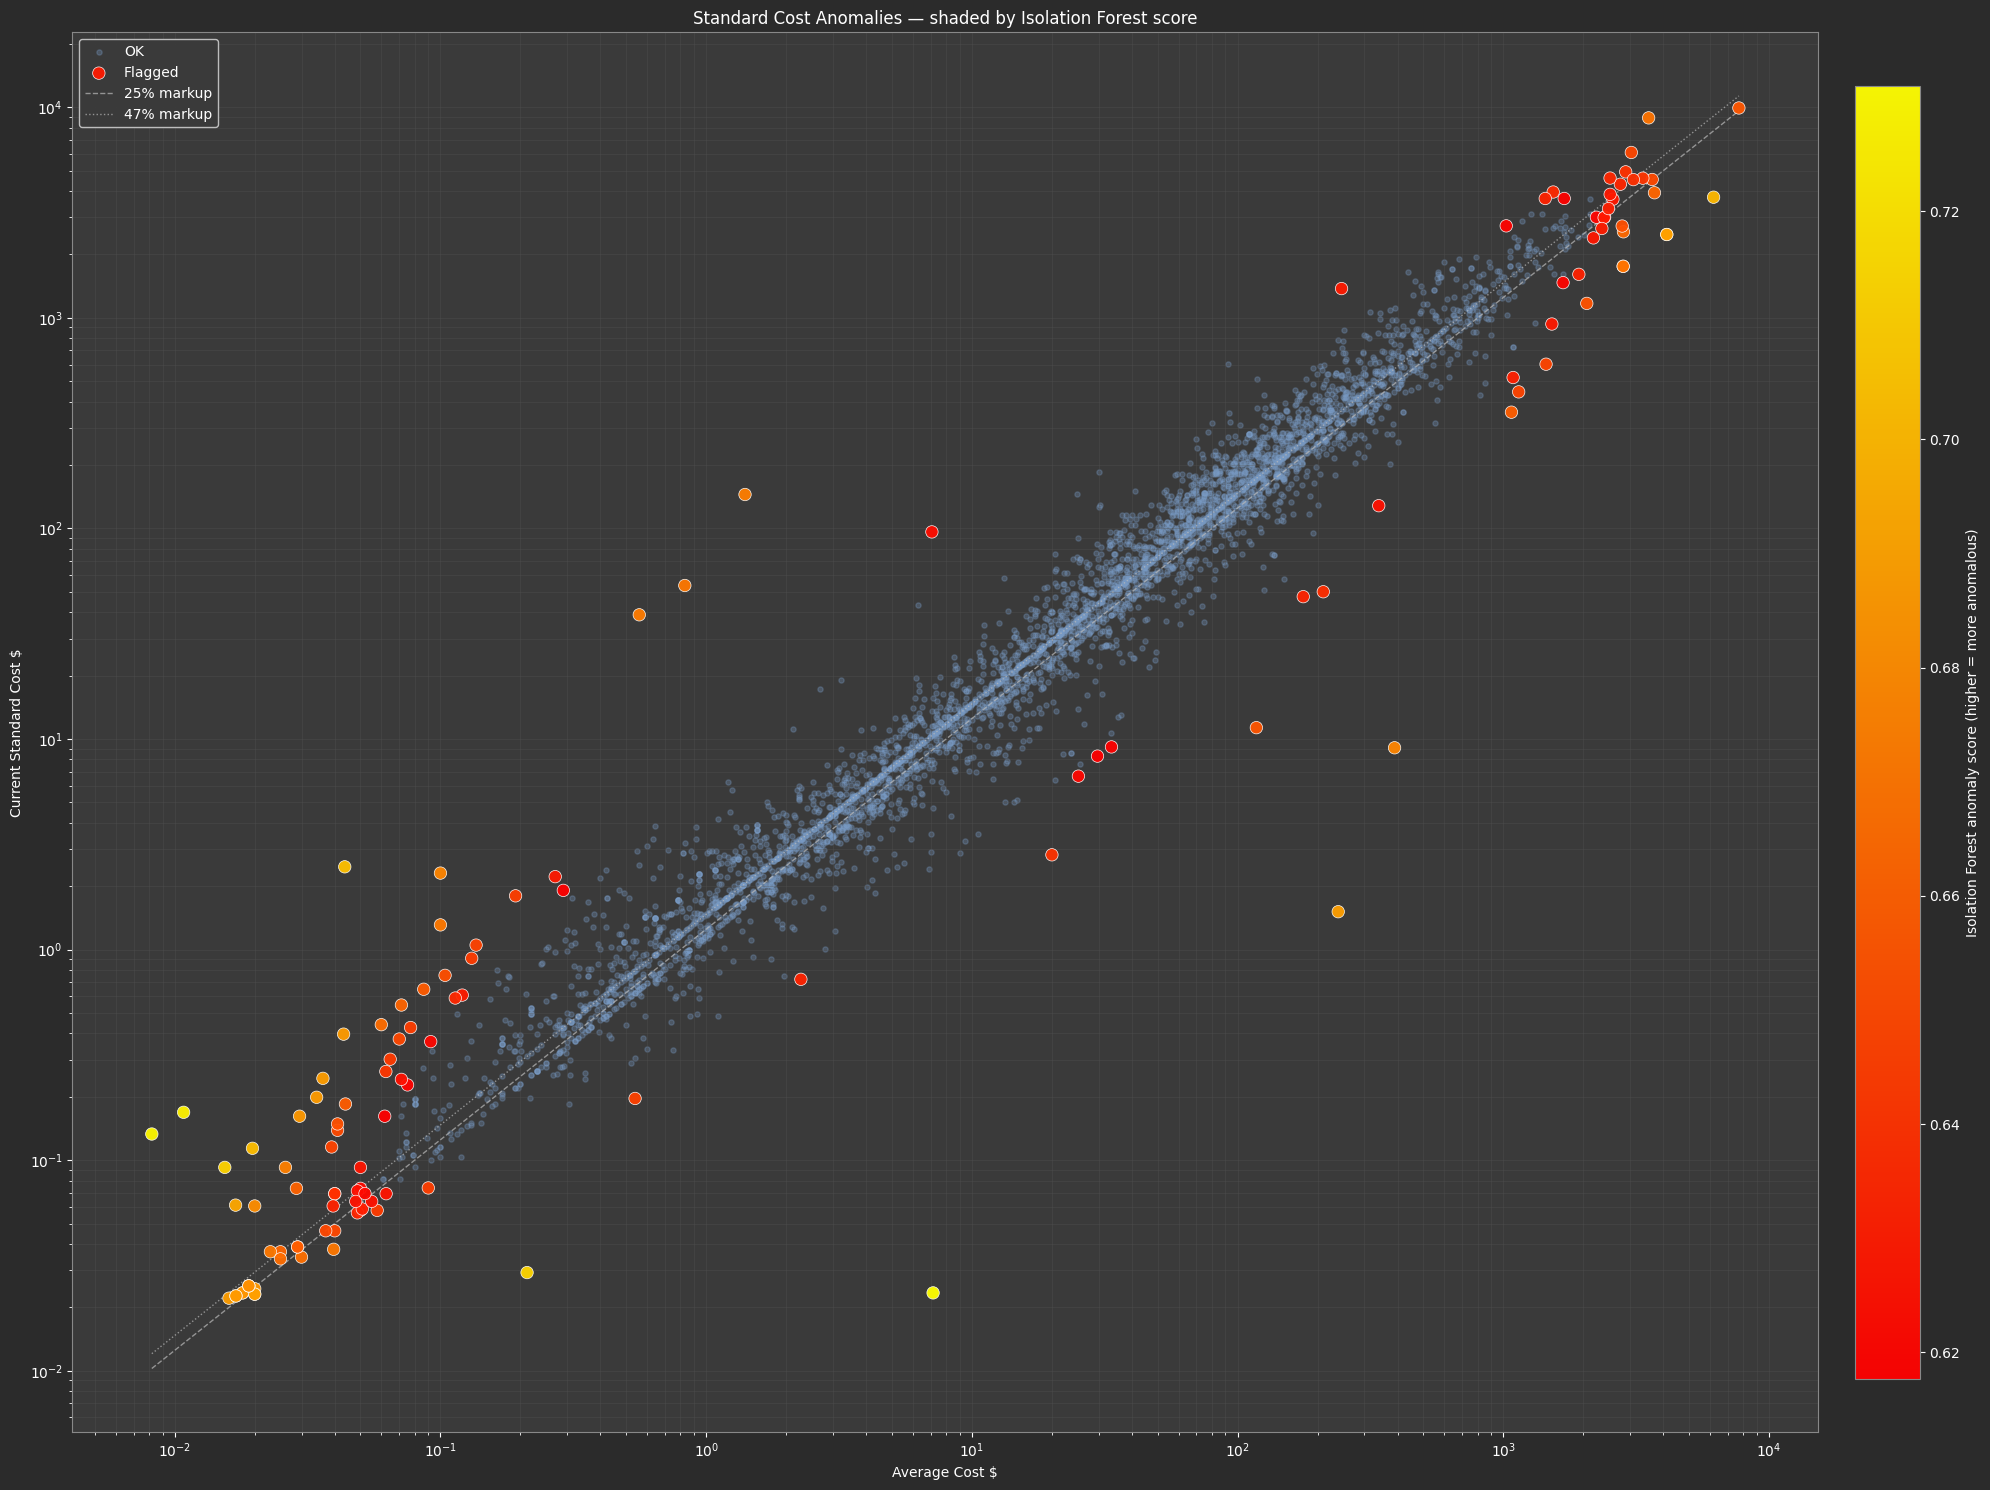

In [10]:
plt.rcParams.update({'figure.facecolor': '#2b2b2b', 'axes.facecolor': '#3a3a3a', 'axes.edgecolor': '#888', 'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white', 'text.color': 'white', 'grid.color': '#555', 'axes.titlecolor': 'white'})
fig, ax = plt.subplots(figsize=(20, 15))

bg = anom[~anom['flag']]
ax.scatter(bg['avg_cost'], bg['std_cost'], c='#7a9cc6', s=14, alpha=0.30, zorder=1, label='OK')
fg = anom[anom['flag']]
sc = ax.scatter(fg['avg_cost'], fg['std_cost'], c=fg['score'], cmap='autumn', s=80, alpha=0.95, edgecolors='white', linewidths=0.5, zorder=3, label='Flagged')
xr = np.array([anom['avg_cost'].min(), anom['avg_cost'].max()])
for m, ls in zip([0.25, 0.47], ['--', ':']):
    ax.plot(xr, xr * (1 + m), ls, color='#bbb', lw=1, alpha=0.7, label=f'{int(m*100)}% markup')

cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Isolation Forest anomaly score (higher = more anomalous)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Average Cost $'); ax.set_ylabel('Current Standard Cost $')
ax.set_title('Standard Cost Anomalies — shaded by Isolation Forest score')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Isolation Table

In [11]:
flagged = anom[anom['flag']].sort_values('score', ascending=False)
review_cols = ['item_no', 'item_desc_1', 'item_desc_2', 'avg_cost', 'std_cost', 'ratio', 'score']
print(f'Total Flagged = {len(flagged)}')
flagged[review_cols].style.format({'avg_cost': '${:,.2f}', 'std_cost': '${:,.2f}', 'ratio': '{:.3f}', 'score': '{:.3f}'})

Total Flagged = 129


,item_no,item_desc_1,item_desc_2,avg_cost,std_cost,ratio,score
5459,911SJ50032,3M BUMP ON SJ5003 BLACK,nan,$7.14,$0.02,0.003,0.731
3731,3131,FLEXIBLE VINYL TUBING,.120 X .170 CLEAR,$0.01,$0.13,16.232,0.729
3788,313S2,FLEXIBLE VINYL TUBING,1/8 X 3/16 CLEAR,$0.01,$0.17,15.624,0.726
5483,911SJ53120,3M BUMP ON SJ5312 CLEAR,nan,$0.21,$0.03,0.138,0.713
911,049SP250,MOLDED ACRYLIC,SPHERES 250 DIA.,$0.02,$0.09,5.987,0.712
5628,936B85011,8 1/2 X 11 STYLE B SIGN,HOLDER,$0.04,$2.47,56.644,0.703
3786,313S1A,FLEXIBLE VINYL TUBING,1/16 X 1/8 CLEAR,$0.02,$0.11,5.804,0.702
2084,181075048096,KYNAR SHEET,.750 X 48 X 96 NAT.,"$6,179.09","$3,738.65",0.605,0.700
686,0440012510,EXTRUDED ACRYLIC ROD,1/8' ROUND,$0.02,$0.06,3.609,0.692
2078,181050048096,KYNAR SHEET,.500 X 48 X 96 NAT.,"$4,119.40","$2,487.08",0.604,0.689


Above items should either be excluded or fixed from the analysis.